### 1. Setup and Imports
Loading the required Python libraries to process and visualize the C3D biomechanics data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import ezc3d
import pandas as pd

In [2]:
# Defining the target directories of all .c3d, .mot, and .sto files available for processing.
database = 'DB4'
participant = 'P02'

c3d_folder = f'../data/{database}_retargeted/{participant}'
ik_folder = f'../results/{database}/{participant}/IK'
id_folder = f'../results/{database}/{participant}/ID'
grf_folder = f'../results/{database}/{participant}/ID/GRF'

In [3]:
# Get all raw filenames from the three folders
all_c3d = sorted([f for f in os.listdir(c3d_folder) if f.endswith('.c3d')])
all_ik = os.listdir(ik_folder)
all_id = os.listdir(id_folder)
all_grf = [f for f in os.listdir(c3d_folder) if f.endswith('.mot')]

# Match IK/ID files to each C3D file
c3d_files, ik_files, id_files, grf_files = [], [], [], []

for c3d_name in all_c3d:
    base_name = c3d_name.replace('.c3d', '')

    # Find all IK segments for this trial (e.g., segment_0, segment_1)
    matching_ik = sorted([f for f in all_ik if f.startswith(base_name) and f.endswith('.mot')])

    for ik_file in matching_ik:
        # Construct the expected ID name by replacing the IK suffix with the ID suffix
        seg_id = ik_file.replace('_ik.mot', '_id.sto')
        seg_grf = ik_file.replace('_ik.mot', '_grf.mot')

        if seg_id in all_id:
            c3d_files.append(c3d_name)
            ik_files.append(ik_file)
            id_files.append(seg_id)
            grf_files.append(seg_grf)
        else:
            print(f"⚠️ Warning: Found IK for {c3d_name} but no matching ID")

print(f"Ready to process {len(ik_files)} unique segments across {len(set(c3d_files))} trials.")

⚠️ Warning: Found IK for DB4_P02_T04_relabeled.c3d but no matching ID
Ready to process 4 unique segments across 4 trials.


### 2. Metadata Extraction (Baseline)
Since the dataset is sourced from a standardized **AddBiomechanics** pipeline, we assume internal consistency across trials. We extract sampling rates and labels from the first available file to define the reference parameters for batch processing.

In [20]:
# Extract C3D Metadata
c_ref = ezc3d.c3d(os.path.join(c3d_folder, c3d_files[0]))
base_point_rate = c_ref['parameters']['POINT']['RATE']['value'][0]
base_analog_rate = c_ref['parameters']['ANALOG']['RATE']['value'][0]
analog_labels = c_ref['parameters']['ANALOG']['LABELS']['value']

# Extract IK/ID Column Labels
ik_ref_cols = pd.read_csv(os.path.join(ik_folder, ik_files[0]), sep='\t', skiprows=10, nrows=0).columns.tolist()
id_ref_cols = pd.read_csv(os.path.join(id_folder, id_files[0]), sep='\t', skiprows=10, nrows=0).columns.tolist()
#grf_ref_cols = pd.read_csv(os.path.join(grf_folder, grf_files[0]), sep='\t', skiprows=6, nrows=0).columns.tolist()

print(f"Metadata loaded for database: {database}, participant: {participant}")
print(f"  > C3D Points:  {base_point_rate} Hz")
print(f"  > C3D Analogs: {base_analog_rate} Hz")
print(f"  > Analog labels:  {analog_labels}")
#print(f"  > IK Columns:  {ik_ref_cols} found")
#print(f"  > ID Columns:  {id_ref_cols} found")
#print(f"  > GRF Columns:  {grf_ref_cols} found")

Metadata loaded for database: DB4, participant: P02
  > C3D Points:  250.0 Hz
  > C3D Analogs: 2000.0 Hz
  > Analog labels:  ['Fx1', 'Fy1', 'Fz1', 'Mx1', 'My1', 'Mz1', 'Fx2', 'Fy2', 'Fz2', 'Mx2', 'My2', 'Mz2', 'Torque', 'Velocity', 'Position', 'Sync', 'Fx3', 'Fy3', 'Fz3', 'Mx3', 'My3', 'Mz3', 'Fx4', 'Fy4', 'Fz4', 'Mx4', 'My4', 'Mz4', 'NA', 'NA', 'NA', 'NA', 'Fx5', 'Fy5', 'Fz5', 'Mx5', 'My5', 'Mz5']


In [5]:
# --- DIAGNOSTIC: CHECKING ANALOG SCALING ---
idx_fz1 = [i for i, s in enumerate(analog_labels) if 'Fz1' in s][0]

# 1. Check Units
units = c_ref['parameters']['ANALOG']['UNITS']['value']
fz1_unit = units[idx_fz1] if idx_fz1 < len(units) else "Unknown"

# 2. Check Scale Factors
gen_scale = c_ref['parameters']['ANALOG']['GEN_SCALE']['value'][0]
scales = c_ref['parameters']['ANALOG']['SCALE']['value']
fz1_scale = scales[idx_fz1]

# 3. Check Offsets
offsets = c_ref['parameters']['ANALOG']['OFFSET']['value']
fz1_offset = offsets[idx_fz1]

print(f"Channel: {analog_labels[idx_fz1]}")
print(f"  > Stored Units: {fz1_unit}")
print(f"  > General Scale: {gen_scale}")
print(f"  > Channel Scale: {fz1_scale}")
print(f"  > Offset: {fz1_offset}")
print(f"  > Total Multiplier: {gen_scale * fz1_scale}")

Channel: Fz1
  > Stored Units: V
  > General Scale: 1.0
  > Channel Scale: -100.0
  > Offset: 0
  > Total Multiplier: -100.0


### Scaling factor and Inversion correction Functions

In [5]:
def get_scaling_factor(vGRF_raw, grf_folder, grf_filename, default=10.0):
    """ Calculates scaling factor using grf.mot reference. 
    Falls back to default if file is missing. """

    # 1. Check if the folder contains any files at all
    if not any(f.endswith('.mot') for f in os.listdir(grf_folder)):
        print(f"        ! No .mot files found in folder. Using default scaling: {default}x")
        return default

    # 2. If folder has files, look for the specific MOT
    grf_path = os.path.join(grf_folder, grf_filename) if grf_filename else ""
    if not os.path.exists(grf_path):
        print(f"        ! Reference file _grf.mot not found. Using default: {default}x")
        return default

    try:
        df_ref = pd.read_csv(grf_path, sep='\t', skiprows=6)
        # Calculate scaling based on vertical peak comparison
        mot_peak = np.max(np.abs(df_ref.filter(like='_vy').values))
        c3d_peak = np.max(np.abs(vGRF_raw))

        factor = round(mot_peak / c3d_peak, 1)
        print(f"        Scaling calculated from MOT: {factor}x")
        return factor
    except Exception:
        # Fallback if file is corrupted or unreadable
        return default

In [6]:
def apply_inversion_correction(vGRF1, vGRF2):
    """ Ensures vertical GRF is positive."""
    inverted = False
    if np.abs(np.min(vGRF1)) > np.abs(np.max(vGRF1)):
        vGRF1 *= -1
        inverted = True
    if np.abs(np.min(vGRF2)) > np.abs(np.max(vGRF2)):
        vGRF2 *= -1
        inverted = True
    return vGRF1, vGRF2, inverted

### 3. Vertical GRF Extraction (If needed: Scaling / Inversion)

In [28]:
GRF_SOURCE = 'C3D' # 'C3D' or 'MOT'
vGRF_data = {} # Dictionary to store GRF data { 'c3d_name': (vGRF1, vGRF2) }
total_inversions = 0

if GRF_SOURCE == 'C3D':
    # Define target labels (UPDATE if needed); Based on metadata: 'Fz1' & 'Fz2'
    target_vGRF1, target_vGRF2 = 'Fz1', 'Fz2'
    # Find indices based on C3D analog labels
    idx1 = [i for i, s in enumerate(analog_labels) if target_vGRF1 in s][0]
    idx2 = [i for i, s in enumerate(analog_labels) if target_vGRF2 in s][0]
    current_rate = base_analog_rate
else: # 'MOT'
    # Define target labels (UPDATE if needed); Based on metadata: 'ground_force_calcn_l_vy' & 'ground_force_calcn_r_vy'
    target_vGRF1, target_vGRF2 = '_l_vy', '_r_vy'
    current_rate = base_point_rate

print(f"Extracting vGRF from {GRF_SOURCE} files...")
for i in range(len(c3d_files)):
    c3d_name = c3d_files[i]
    grf_name = grf_files[i] if i < len(grf_files) else None

    if GRF_SOURCE == 'C3D':
        df_c3d = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
        units = df_c3d['parameters']['ANALOG']['UNITS']['value'][idx1]
        vGRF1_raw = df_c3d['data']['analogs'][0, idx1, :]
        vGRF2_raw = df_c3d['data']['analogs'][0, idx2, :]

        # Scaling
        if 'V' in units.upper():
            print(f"    > [{c3d_name}] Units in V. Performing scaling...")
            scaling_factor = get_scaling_factor(vGRF1_raw, grf_folder, grf_name, default=10.0)
        else: # 'N'
            scaling_factor = 1.0
            print(f"    > [{c3d_name}] Units already in {units}. No scaling.")
        vGRF1, vGRF2 = vGRF1_raw * scaling_factor, vGRF2_raw * scaling_factor

    else: # 'MOT' Source
        df_grf = pd.read_csv(os.path.join(grf_folder, grf_name), sep='\t', skiprows=6)
        col1 = [c for c in df_grf.columns if target_vGRF1 in c][0]
        col2 = [c for c in df_grf.columns if target_vGRF2 in c][0]
        vGRF1, vGRF2 = df_grf[col1].values, df_grf[col2].values

    # Inversion
    vGRF1, vGRF2, inverted = apply_inversion_correction(vGRF1, vGRF2)
    if inverted:
        total_inversions += 1

    vGRF_data[c3d_name] = (vGRF1, vGRF2)

print(f"\nCompleted: {len(vGRF_data)} trials processed at {current_rate} Hz.")
print(f"⚠️ {total_inversions} trials needed inversion correction")

Extracting vGRF from C3D files...
    > [DB4_P02_T01_relabeled.c3d] Units in V. Performing scaling...
        Scaling calculated from MOT: 11.9x
    > [DB4_P02_T02_relabeled.c3d] Units in V. Performing scaling...
        Scaling calculated from MOT: 11.6x
    > [DB4_P02_T03_relabeled.c3d] Units in V. Performing scaling...
        Scaling calculated from MOT: 11.7x
    > [DB4_P02_T04_relabeled.c3d] Units in V. Performing scaling...
        Scaling calculated from MOT: 11.5x

Completed: 4 trials processed at 2000.0 Hz.
⚠️ 4 trials needed inversion correction


### Visualizing Vertical GRF
This section provides the visualization of the vertical GRF from both force plates for only one file in the dataset to verify the extraction and inversion correction. A reference line is plotted at 20N to visually verify the threshold  for subsequent gait event detection (Heel Strike and Toe-Off).

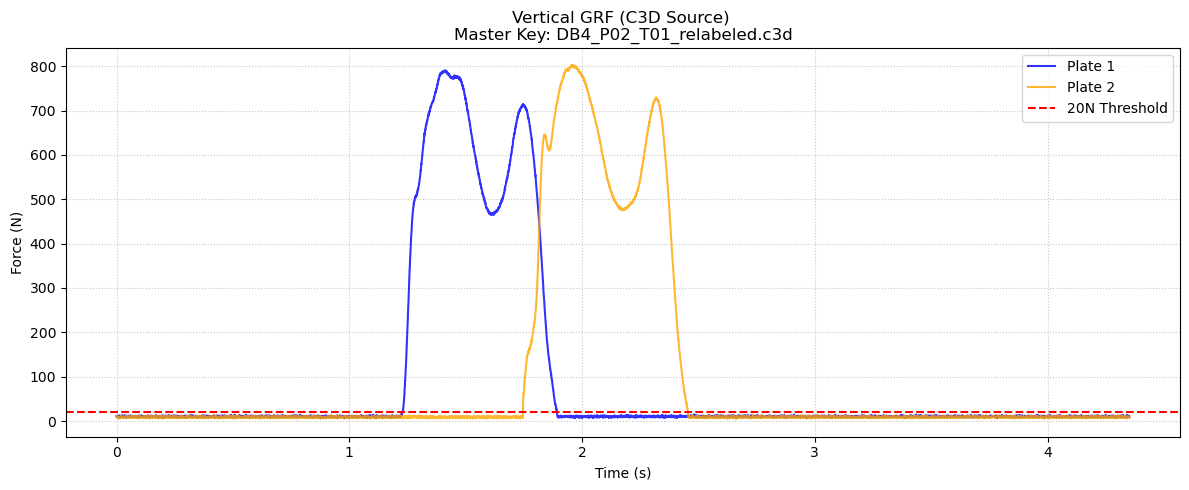

In [29]:
sample_idx = 0
sample_name = c3d_files[sample_idx]

# Retrieve corrected GRF data
vGRF1_plot, vGRF2_plot = vGRF_data[sample_name]
# Time vector based on the current rate
time = np.arange(len(vGRF1_plot)) / current_rate

plt.figure(figsize=(12, 5))
plt.plot(time, vGRF1_plot, label='Left' if GRF_SOURCE == 'MOT' else 'Plate 1', color='blue', alpha=0.8)
plt.plot(time, vGRF2_plot, label='Right' if GRF_SOURCE == 'MOT' else 'Plate 2', color='orange', alpha=0.8)
plt.axhline(y=20, color='red', linestyle='--', label='20N Threshold') 

plt.title(f"Vertical GRF ({GRF_SOURCE} Source) \nMaster Key: {sample_name}")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Event Detection Functions

In [9]:
def detect_raw_events(force_data, threshold=20):
    """ Detects all frame transitions above/below a threshold."""
    contact = (force_data > threshold).astype(int)
    transitions = np.diff(contact)

    # +1 = Heel Strike (HS), -1 = Toe-Off (TO)
    hs_frames = np.where(transitions == 1)[0] + 1
    to_frames = np.where(transitions == -1)[0] + 1

    return hs_frames, to_frames

In [10]:
def filter_gait_events(hs_raw, to_raw, sampling_rate):
    """ Filters events using a generalized stance window (0.3s to 2.0s).
    Works for almost all walking speeds without needing external speed data. """
    # Broad window: 0.3s is a very fast run, 2.0s is a very slow shuffle
    min_stance, max_stance = 0.5, 1.0   # MODIFY if needed

    paired_hs, paired_to = [], []

    # Loop through heel strikes and find the matching toe-off
    for hs in hs_raw:
        # Find the first toe-off that happens after this heel strike
        possible_tos = to_raw[to_raw > hs]

        if len(possible_tos) > 0:
            to = possible_tos[0]
            stance_duration = (to - hs) / sampling_rate

            # Validate the stance phase duration
            if min_stance < stance_duration < max_stance:
                paired_hs.append(hs)
                paired_to.append(to)

    return np.array(paired_hs), np.array(paired_to)

In [11]:
def detect_hs2_by_ref(marker_z, to_frame, ref_height, buffer=2.0):
    """ Finds HS2 by looking for when the heel marker descends back
    to the height it had at HS1. """
    # Start looking after Toe-Off
    search_start = to_frame + 10
    swing_data = marker_z[search_start:]

    if len(swing_data) < 5: return None

    # Find the first frame where the heel height is <= ref_height + buffer
    # AND the marker is moving downwards (negative velocity)
    for i in range(1, len(swing_data)):
        current_height = swing_data[i]
        velocity = swing_data[i] - swing_data[i-1]
        if current_height <= (ref_height + buffer) and velocity < 0:
            return search_start + i

    return None

### 4. Gait Events Segmentation



In [12]:
threshold_value = 20  # MODIFY if needed
gait_events = {} # Dictionary to store gait events { 'c3d_name': () }
frame_ratio = current_rate / base_point_rate

print(f"Detecting events... Source: {GRF_SOURCE} ({current_rate}Hz) using {threshold_value}N threshold")

for c3d_name in c3d_files:
    # 1. Get the corrected forces & detect force plate events
    vGRF1, vGRF2 = vGRF_data[c3d_name]
    h1_r, t1_r = detect_raw_events(vGRF1, threshold=threshold_value)
    h2_r, t2_r = detect_raw_events(vGRF2, threshold=threshold_value)

    # 2. Filter for valid stance phases
    hs_list_L, to_list_L = filter_gait_events(h1_r, t1_r, current_rate)
    hs_list_R, to_list_R = filter_gait_events(h2_r, t2_r, current_rate)

    # 3. Load Marker data for HS2 detection
    df_c3d = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
    m_data = df_c3d['data']['points'][:3, :, :]
    labels = df_c3d['parameters']['POINT']['LABELS']['value']
    l_hee_idx, r_hee_idx = labels.index('LHEE'), labels.index('RHEE')

    # 4. Process the first step for each side
    # We check if a step was actually detected first to avoid "Index out of range" errors

    # --- LEFT SIDE ---
    res_L = (None, None)
    if len(hs_list_L) > 0:
        h1_a, t1_a = hs_list_L[0], to_list_L[0]
        # Convert to camera frames
        h1_p = int(np.round(h1_a / frame_ratio))
        t1_p = int(np.round(t1_a / frame_ratio))
        # Get the "Reference Height" at the verified HS1
        ref_z_L = m_data[2, l_hee_idx, h1_p]
        # Use that height to find HS2
        h2_p = detect_hs2_by_ref(m_data[2, l_hee_idx, :], t1_p, ref_z_L)
        # Convert back to Analog Rate for the dictionary
        h2_a = int(h2_p * frame_ratio) if h2_p else None
        res_L = (h1_a, h2_a)

    # --- RIGHT SIDE ---
    res_R = (None, None)
    if len(hs_list_R) > 0:
        h1_a, t1_a = hs_list_R[0], to_list_R[0]
        h1_p = int(np.round(h1_a / frame_ratio))
        t1_p = int(np.round(t1_a / frame_ratio))
        ref_z_R = m_data[2, r_hee_idx, h1_p]
        h2_p = detect_hs2_by_ref(m_data[2, r_hee_idx, :], t1_p, ref_z_R)
        h2_a = int(h2_p * frame_ratio) if h2_p else None
        res_R = (h1_a, h2_a)

    # 4. Store in dictionary
    gait_events[c3d_name] = {'left': res_L, 'right': res_R}

# --- SUMMARY TABLE ---
print(f"\n{'Trial Name':<40} | {'Left HS1-HS2':<15} | {'Right HS1-HS2':<15}")
print("-" * 75)
for name, side_data in gait_events.items():
    l_status = "Found" if side_data['left'][1] else "Partial"
    r_status = "Found" if side_data['right'][1] else "Partial"
    print(f"{name:<40} | {l_status:<15} | {r_status:<15}")

Detecting events... Source: MOT (250.0Hz) using 20N threshold

Trial Name                               | Left HS1-HS2    | Right HS1-HS2  
---------------------------------------------------------------------------
DB4_P02_T01_relabeled.c3d                | Found           | Found          
DB4_P02_T02_relabeled.c3d                | Found           | Found          
DB4_P02_T03_relabeled.c3d                | Found           | Found          
DB4_P02_T04_relabeled.c3d                | Found           | Found          


### Visualizing of Filtered Gait Events
This section provides a visual verification of the gait event detection and steady-state filtering.

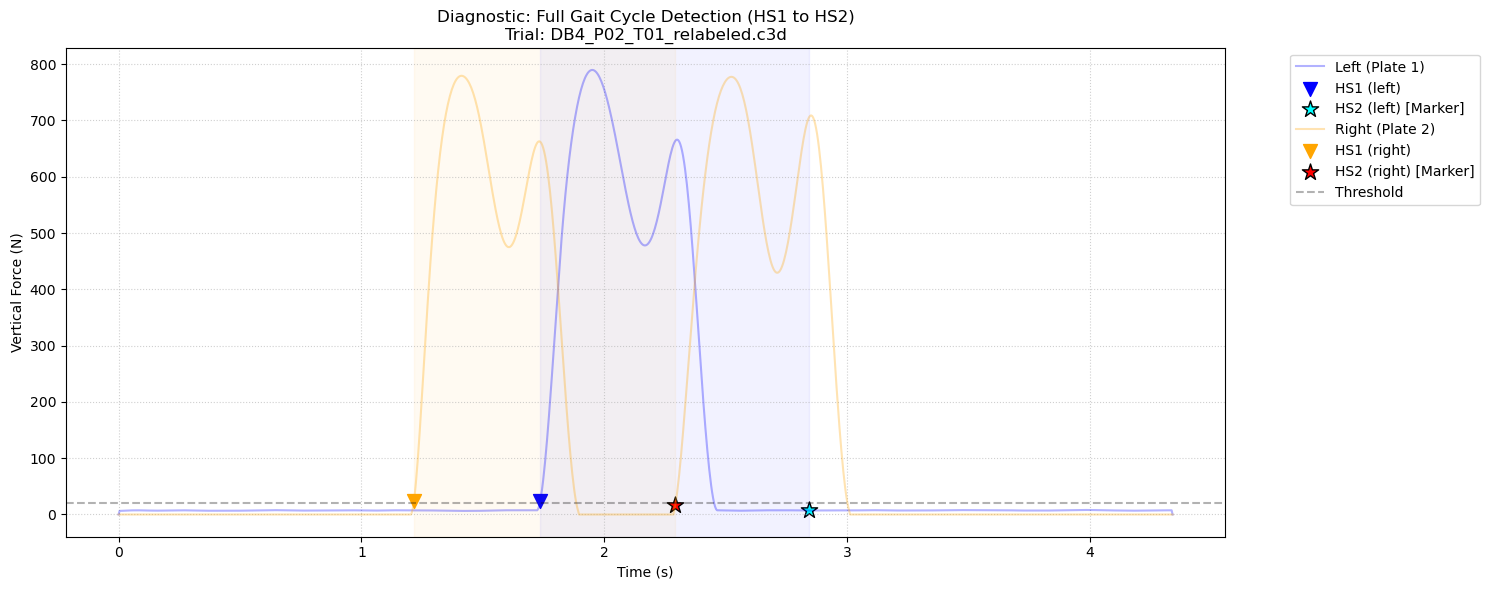

In [13]:
sample_idx = 0
sample_name = c3d_files[sample_idx]

vGRF_L, vGRF_R = vGRF_data[sample_name]
events = gait_events[sample_name]
time_vec = np.arange(len(vGRF_L)) / current_rate

plt.figure(figsize=(15, 6))

configs = [
    ('left', vGRF_L, 'blue', 'cyan', 'Left (Plate 1)'),
    ('right', vGRF_R, 'orange', 'red', 'Right (Plate 2)')
]

for side, signal, color_main, color_hs2, label_base in configs:
    hs1, hs2 = events[side]

    # Plot the Force Signal
    plt.plot(time_vec, signal, color=color_main, alpha=0.3, label=label_base)
    # Plot HS1 (Start of Cycle - Force Plate)
    if hs1 is not None:
        plt.scatter(hs1/current_rate, signal[int(hs1)], 
                    color=color_main, marker='v', s=100, label=f'HS1 ({side})')
    # Plot HS2 (End of Cycle - Marker Based)
    if hs2 is not None:
        # We cap the index at the signal length to avoid errors
        idx_hs2 = min(int(hs2), len(signal) - 1)
        plt.scatter(hs2/current_rate, signal[idx_hs2], 
                    color=color_hs2, marker='*', s=150, edgecolors='black', 
                    label=f'HS2 ({side}) [Marker]')

        # Draw a vertical span to highlight the full cycle
        plt.axvspan(hs1/current_rate, hs2/current_rate, color=color_main, alpha=0.05)

plt.axhline(y=threshold_value, color='black', linestyle='--', alpha=0.3, label='Threshold')
plt.title(f"Diagnostic: Full Gait Cycle Detection (HS1 to HS2)\nTrial: {sample_name}")
plt.xlabel("Time (s)")
plt.ylabel("Vertical Force (N)")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Time-Normalization Functions

In [14]:
def interp_101(data, original_len):
    """Interpolates 1D, 2D, or 3D data to 101 points."""
    old_x = np.linspace(0, 100, original_len)
    new_x = np.linspace(0, 100, 101)

    if data.ndim == 1:
        return np.interp(new_x, old_x, data)

    # For multi-dim (Markers/IK/ID): reshape to flatten all spatial dimensions, interpolate, & restore original spatial shape.
    original_shape = data.shape
    # 'data' shape is usually (D1, D2, Time) -> flatten to (D1*D2, Time)
    flat_data = data.reshape(-1, original_len)
    interp_flat = np.array([np.interp(new_x, old_x, row) for row in flat_data])

    # Restore to (D1, D2, 101)
    return interp_flat.reshape(original_shape[:-1] + (101,))

### 5. Time-Normalization to 101 Points (Batch Processing)
This section interpolates both the **Kinetics**, **Kinematics**, **IK**, and **ID** to a standard 101-point vector, representing 0% to 100% of the gait cycle.

In [15]:
time_normalized_data = {} # Dictionary { 'c3d_name': ('kinematics', 'GRF', 'ik', 'id', 'side_label') }
frame_ratio = current_rate / base_point_rate

for i, c3d_name in enumerate(c3d_files):
    # 1. Load data streams
    # Load Marker points (3 x Markers x Frames)
    c = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
    m = c['data']['points'][:3, :, :]
    # Pulls the pre-processed GRF
    vGRF_L, vGRF_R = vGRF_data[c3d_name]
    # Load IK/ID and transpose so Time is the last dimension
    ik = pd.read_csv(os.path.join(ik_folder, ik_files[i]), sep='\t', skiprows=10).values.T
    id_ = pd.read_csv(os.path.join(id_folder, id_files[i]), sep='\t', skiprows=10).values.T

    ev = gait_events[c3d_name]
    cycles = {k: [] for k in ['kinematics', 'GRF', 'ik', 'id', 'side_label']}

    # Process both sides
    for side_idx, side_key, grf_signal in [(0, 'left', vGRF_L), (1, 'right', vGRF_R)]:
        hs1, hs2 = ev[side_key]
        if hs2 is None: continue # Skip if second strike wasn't found (trial ended too early)

        # 1. Define 100% Cycle Window (2 consecutive heel-strike for one side)
        s_a, e_a = int(hs1), int(hs2) # analog
        s_p, e_p = int(np.round(s_a/frame_ratio)), int(np.round(e_a/frame_ratio)) # point

        # 2. Interpolate 
        cycles['kinematics'].append(interp_101(m[:, :, s_p:e_p], e_p - s_p))
        cycles['GRF'].append(interp_101(grf_signal[s_a:e_a], e_a - s_a))
        cycles['ik'].append(interp_101(ik[:, s_p:e_p], e_p - s_p))
        cycles['id'].append(interp_101(id_[:, s_p:e_p], e_p - s_p))
        cycles['side_label'].append(side_idx)

    time_normalized_data[c3d_name] = {k: np.array(v) for k, v in cycles.items()}

print(f"Total completed gait cycles found: {sum(len(v['side_label']) for v in time_normalized_data.values())}")

Total completed gait cycles found: 8


### Integrated Visualization
This section provides a visual verification of the time-normalized data for the entire trial. 

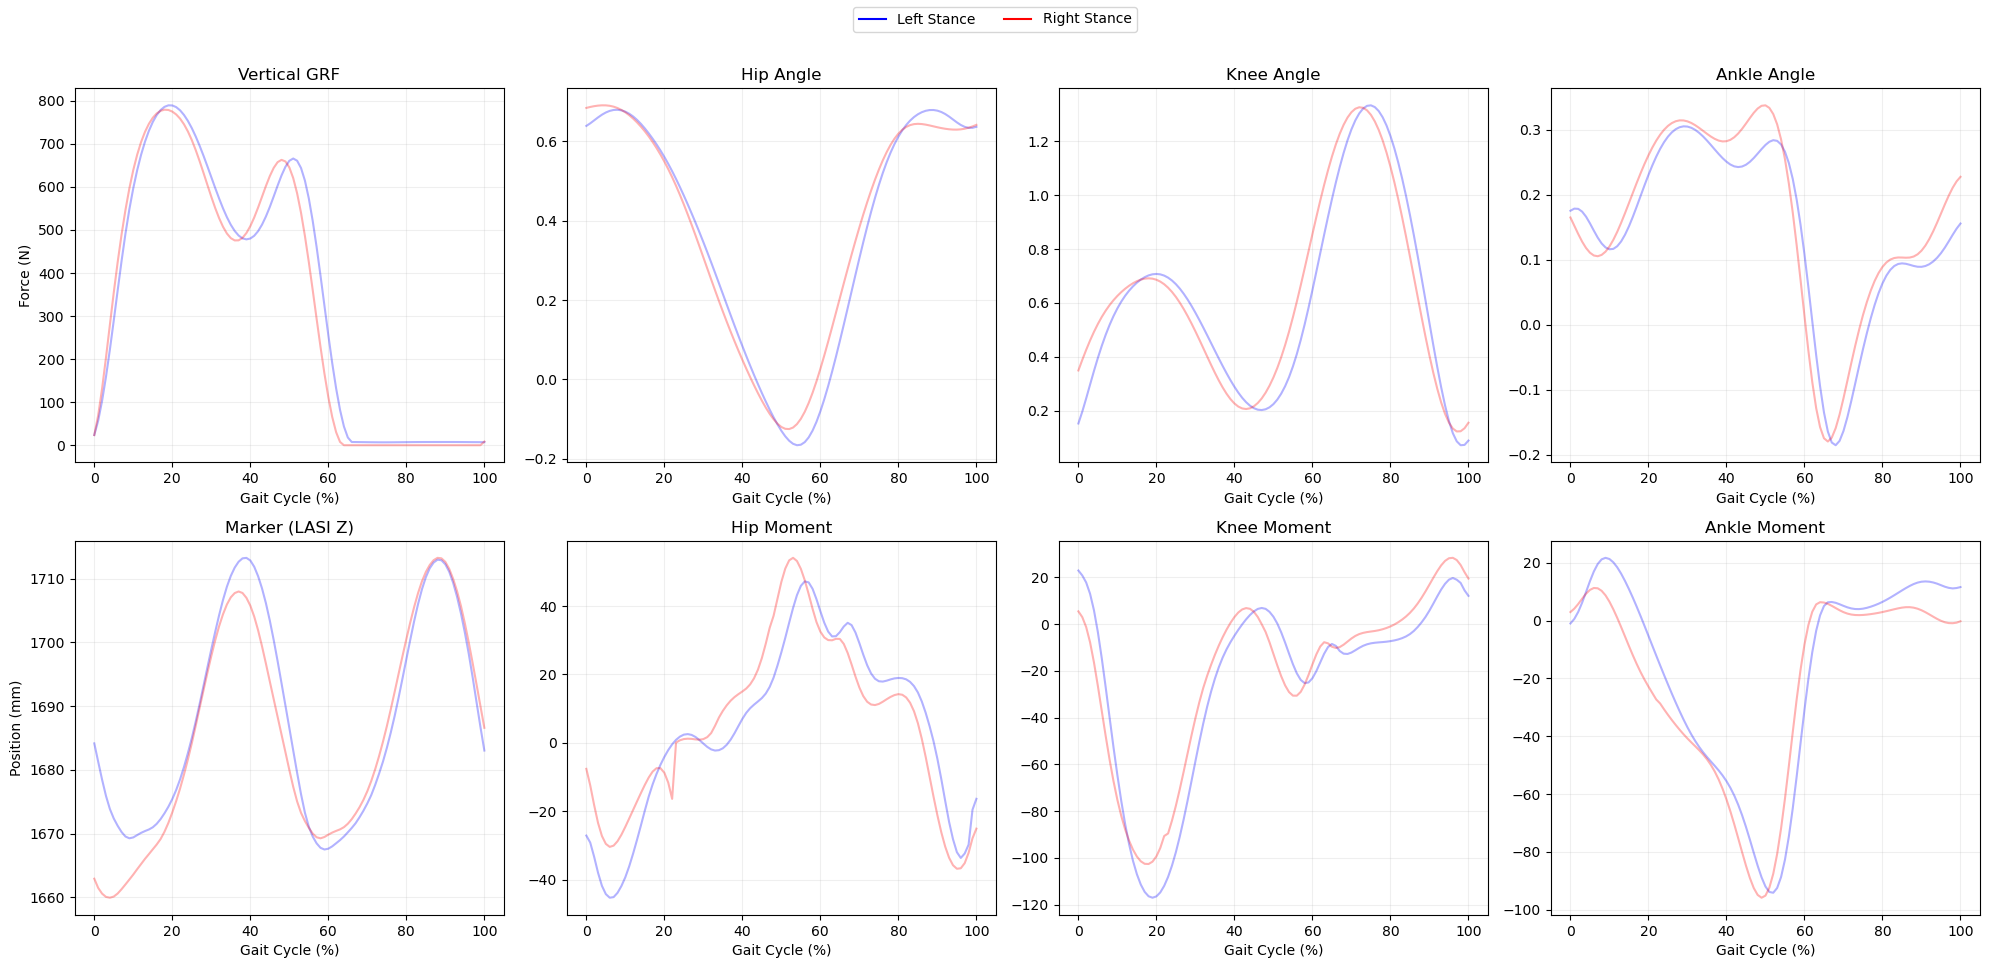

In [16]:
sample_idx = 0
sample_file = c3d_files[sample_idx] 
data = time_normalized_data[sample_file]
normalized_time = np.linspace(0, 100, 101)

# 1. Identify IK/ID Column Indices (Searching for Sagittal plane angles/moments)
# We look for the "active" side columns based on common OpenSim naming
ik_cols = [pd.read_csv(os.path.join(ik_folder, ik_files[0]), sep='\t', skiprows=10).columns]
id_cols = [pd.read_csv(os.path.join(id_folder, id_files[0]), sep='\t', skiprows=10).columns]

def get_col_idx(headers, joint, side_idx):
    side_pref = '_l' if side_idx == 0 else '_r'
    return [i for i, h in enumerate(headers) if joint in h and side_pref in h][0]

# --- PLOTTING ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
joints = ['hip_flexion', 'knee_angle', 'ankle_angle']
titles = ['Vertical GRF', 'Hip Angle', 'Knee Angle', 'Ankle Angle', 
          'Marker (LASI Z)', 'Hip Moment', 'Knee Moment', 'Ankle Moment']

# Iterate through every stance in this file
sides = data['side_label']
for s_idx in range(len(sides)):
    color = 'blue' if sides[s_idx] == 0 else 'red'
    label = 'Left' if sides[s_idx] == 0 else 'Right'
    alpha = 0.3

    # Row 1, Col 0: GRF
    axes[0, 0].plot(normalized_time, data['GRF'][s_idx], color=color, alpha=alpha)

    # Row 2, Col 0: Kinematics (LASI Z)
    m_idx = analog_labels.index('LASI') if 'LASI' in analog_labels else 0
    axes[1, 0].plot(normalized_time, data['kinematics'][s_idx, 2, m_idx, :], color=color, alpha=alpha)

    # Plot IK (Angles) and ID (Moments)
    for j_idx, joint in enumerate(joints):
        # Find the column for the specific side of this stance
        ik_c = get_col_idx(ik_cols[0], joint, sides[s_idx])
        id_c = get_col_idx(id_cols[0], joint, sides[s_idx])

        # IK is Col 1-3 in Row 0
        axes[0, j_idx+1].plot(normalized_time, data['ik'][s_idx, ik_c, :], color=color, alpha=alpha)
        # ID is Col 1-3 in Row 1
        axes[1, j_idx+1].plot(normalized_time, data['id'][s_idx, id_c, :], color=color, alpha=alpha)

# Formatting
for i, ax in enumerate(axes.flat):
    ax.set_title(titles[i])
    ax.set_xlabel("Gait Cycle (%)")
    ax.grid(True, alpha=0.2)
    if i == 0: ax.set_ylabel("Force (N)")
    if i == 4: ax.set_ylabel("Position (mm)")

legend_elements = [Line2D([0], [0], color='blue', label='Left Stance'),
                   Line2D([0], [0], color='red', label='Right Stance')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()